# 03 Model Evaluation
This notebook evaluates the performance of the trained pneumonia classifier using various metrics and visualizations.

In [8]:
import os
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import KFold, StratifiedKFold

import mlflow
import bentoml

# Local project imports
from pneumonia_classifier.ml.model.arch import Net

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.serialization.add_safe_globals([Net])
print("Loading model from BentoML...")
bento_model = bentoml.pytorch.get("pneumonia_classifier_cnn:latest")
model = bentoml.pytorch.load_model(bento_model, weights_only=False)
model.to(device) # Make sure 'device' is defined (e.g., 'cuda' or 'cpu')
model.eval()

Loading model from BentoML...


Net(
  (convolution_block1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pooling11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convolution_block2): Sequential(
    (0): Conv2d(8, 20, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pooling22): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convolution_block3): Sequential(
    (0): Conv2d(20, 10, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pooling33): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (convolution_block4): Sequential(
    (0): Conv2d(10, 20, kernel_size=

## Load Test Data

In [9]:
data_dir = r'j:\Users\ayush\Desktop\code\pneumonia_classifier\artifacts\02_12_2025_08_52_04\data_ingestion\data\data'
test_dir = os.path.join(data_dir, 'test')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False,num_workers=0)

## Generate Predictions

In [10]:
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        prob = F.softmax(output, dim=1)
        pred = output.argmax(dim=1, keepdim=True)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(target.cpu().numpy())
        all_probs.extend(prob.cpu().numpy())

all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()
all_probs = np.array(all_probs)

## Metrics and Confusion Matrix

2026/03/03 02:49:12 INFO mlflow.tracking.fluent: Experiment with name 'cnn_model_evaluation' does not exist. Creating a new experiment.


Classification Report (Default 0.5 Threshold):
              precision    recall  f1-score   support

      NORMAL       0.93      1.00      0.96        27
   PNEUMONIA       1.00      0.93      0.97        30

    accuracy                           0.96        57
   macro avg       0.97      0.97      0.96        57
weighted avg       0.97      0.96      0.96        57



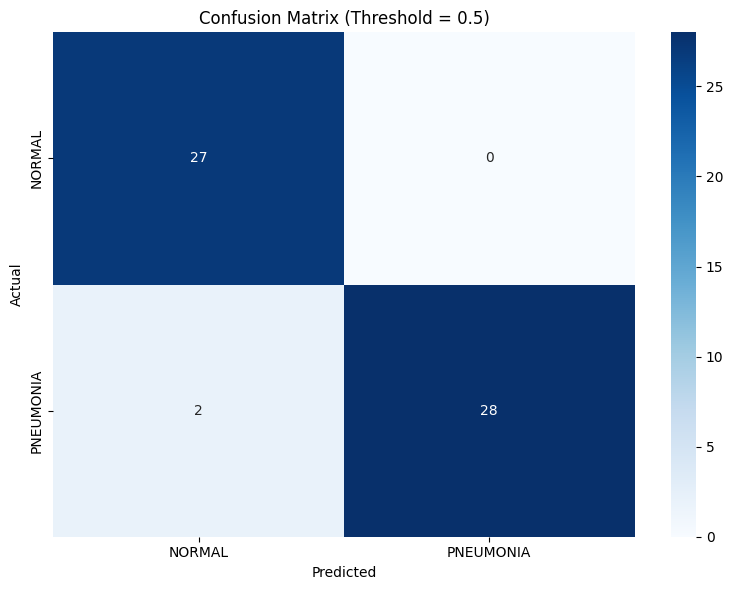


Evaluation metrics and confusion matrix logged to MLflow successfully!


In [11]:
mlflow.set_experiment("cnn_model_evaluation")
with mlflow.start_run(run_name="cnn_evaluation_default_threshold"):
    
    # Generate Classification Report
    print("Classification Report (Default 0.5 Threshold):")
    report = classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA'], output_dict=True)
    print(classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA']))
    
    # Log key metrics to MLflow
    mlflow.log_metrics({
        "eval_accuracy": report['accuracy'],
        "eval_normal_f1": report['NORMAL']['f1-score'],
        "eval_pneumonia_f1": report['PNEUMONIA']['f1-score'],
        "eval_macro_f1": report['macro avg']['f1-score']
    })
    # Generate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix (Threshold = 0.5)')
    
    # Save the plot temporarily and log it as an artifact in MLflow
    plt.tight_layout()
    cm_path = "confusion_matrix.png"
    plt.savefig(cm_path)
    mlflow.log_artifact(cm_path)
    
    # Display the plot in the notebook
    plt.show()
    
    print("\nEvaluation metrics and confusion matrix logged to MLflow successfully!")

### We notice some pretty high values for precission recalla nd accuracy so model is probably great

## ROC AUC and Recall Optimization

ROC AUC Score: 1.0000


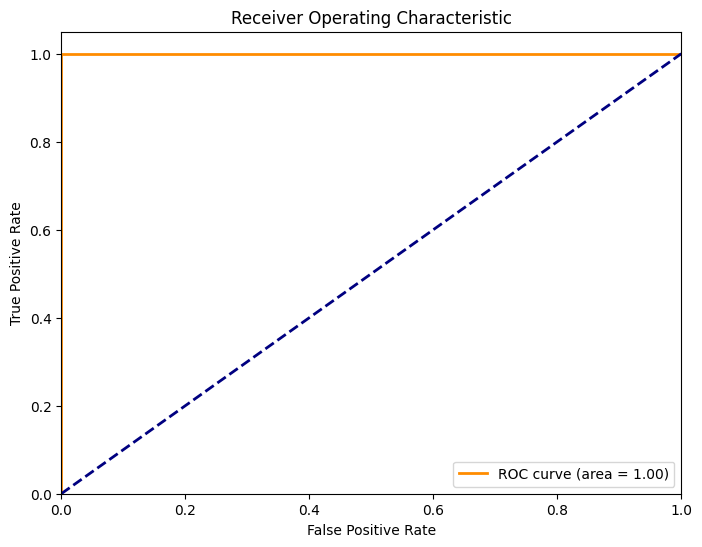


ROC Curve and AUC score logged to MLflow successfully!


In [12]:
with mlflow.start_run(run_name="cnn_evaluation_default_threshold", nested=True):
    
    # 1. Calculate ROC Curve and AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs[:, 1])
    roc_auc = auc(fpr, tpr)
    
    # Log the ROC AUC Score to MLflow
    mlflow.log_metric("eval_roc_auc", roc_auc)
    print(f"ROC AUC Score: {roc_auc:.4f}")
    
    # 2. Plot the ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic")
    plt.legend(loc="lower right")
    
    # 3. Save plot locally and log as an MLflow artifact
    roc_path = "roc_curve.png"
    plt.savefig(roc_path)
    mlflow.log_artifact(roc_path)
    
    plt.show()
    print("\nROC Curve and AUC score logged to MLflow successfully!")


### This graph shows model overfits, other wise how do you get a perfect change of sensitivity and specifity 1.

### Finding the Best Threshold for Recall
We want to maximize recall (sensitivity) for PNEUMONIA. Let's see how metrics change with different thresholds.

In [13]:
def evaluate_threshold(t):
    preds = (all_probs[:, 1] >= t).astype(int)
    report = classification_report(all_labels, preds, target_names=["NORMAL", "PNEUMONIA"], output_dict=True, zero_division=0)
    recall = report["PNEUMONIA"]["recall"]
    precision = report["PNEUMONIA"]["precision"]
    return recall, precision

thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

print(f"{'Threshold':<10} | {'Recall':<10} | {'Precision':<10}")
print('-' * 35)

for t in thresholds_to_test:
    rec, prec = evaluate_threshold(t)
    results.append((t, rec, prec))
    print(f"{t:<10.2f} | {rec:<10.2f} | {prec:<10.2f}")

# Recommend a threshold for > 90% recall
recommended_t, rec_at_t, prec_at_t = next(((t, r, p) for t, r, p in results if r >= 0.9), results[0])

print(f"\nRecommended threshold for high sensitivity (Recall >= 0.90): {recommended_t}")
print(f"Metrics at this threshold -> Recall: {rec_at_t:.2f}, Precision: {prec_at_t:.2f}")

# --- MLflow Logging ---
mlflow.log_params({
    "recommended_threshold": recommended_t
})

mlflow.log_metrics({
    "recall_at_recommended_threshold": rec_at_t,
    "precision_at_recommended_threshold": prec_at_t
})

print("\nThreshold evaluation metrics logged to MLflow successfully!")


Threshold  | Recall     | Precision 
-----------------------------------
0.10       | 1.00       | 0.97      
0.20       | 1.00       | 1.00      
0.30       | 0.93       | 1.00      
0.40       | 0.93       | 1.00      
0.50       | 0.93       | 1.00      
0.60       | 0.90       | 1.00      
0.70       | 0.90       | 1.00      
0.80       | 0.87       | 1.00      
0.90       | 0.80       | 1.00      

Recommended threshold for high sensitivity (Recall >= 0.90): 0.1
Metrics at this threshold -> Recall: 1.00, Precision: 0.97

Threshold evaluation metrics logged to MLflow successfully!


###But this is only if we consider overfit

### Final Metrics with Optimized Threshold

Classification Report (Optimized 0.1 threshold):
              precision    recall  f1-score   support

      NORMAL       1.00      0.96      0.98        27
   PNEUMONIA       0.97      1.00      0.98        30

    accuracy                           0.98        57
   macro avg       0.98      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



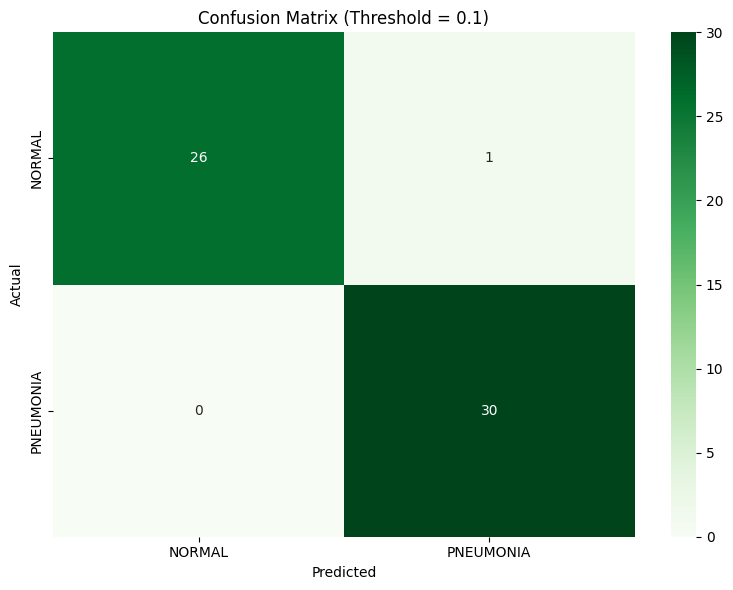


Optimized evaluation metrics and confusion matrix logged to MLflow successfully!


In [14]:
optim_threshold = recommended_t
final_preds = (all_probs[:, 1] >= optim_threshold).astype(int)

# Generate and print the report
print(f"Classification Report (Optimized {optim_threshold} threshold):")
optim_report = classification_report(all_labels, final_preds, target_names=["NORMAL", "PNEUMONIA"], output_dict=True)
print(classification_report(all_labels, final_preds, target_names=["NORMAL", "PNEUMONIA"]))

# --- MLflow Logging ---
# Make sure you are still inside the MLflow run context!
# with mlflow.start_run(run_name="cnn_evaluation_default_threshold", nested=True):

mlflow.log_metrics({
    "optim_eval_accuracy": optim_report['accuracy'],
    "optim_eval_normal_f1": optim_report['NORMAL']['f1-score'],
    "optim_eval_pneumonia_f1": optim_report['PNEUMONIA']['f1-score'],
    "optim_eval_macro_f1": optim_report['macro avg']['f1-score']
})

# Generate Confusion Matrix
cm_final = confusion_matrix(all_labels, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Greens", xticklabels=["NORMAL", "PNEUMONIA"], yticklabels=["NORMAL", "PNEUMONIA"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Threshold = {optim_threshold})")

# Save the plot temporarily and log it as an artifact in MLflow
plt.tight_layout()
cm_optim_path = "confusion_matrix_optim.png"
plt.savefig(cm_optim_path)
mlflow.log_artifact(cm_optim_path)

# Display the plot in the notebook
plt.show()

print("\nOptimized evaluation metrics and confusion matrix logged to MLflow successfully!")


###Let's try to validate via k fold cv the real accuracy of dataset

In [16]:
mlflow.end_run()

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K_FOLDS = 5
BATCH_SIZE = 16
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
EPOCHS_PER_FOLD = 5

# 1. Dataset Initialization
data_dir = r'j:\Users\ayush\Desktop\code\pneumonia_classifier\artifacts\02_12_2025_08_52_04\data_ingestion\data\data\train' # Update to your train path
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(data_dir, transform=transform)
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

results = []

# --- Set up MLflow Experiment ---
mlflow.set_experiment("cnn_cross_validation")

# Start an MLflow Run to encapsulate the entire CV process
with mlflow.start_run(run_name=f"baseline_cv_{K_FOLDS}_folds"):
    
    # Log hyperparameters
    mlflow.log_params({
        "k_folds": K_FOLDS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "momentum": MOMENTUM,
        "weight_decay": WEIGHT_DECAY,
        "epochs_per_fold": EPOCHS_PER_FOLD
    })

    # 2. Cross-Validation Loop
    for fold, (train_ids, val_ids) in enumerate(kfold.split(full_dataset)):
        print(f"\n--- Fold {fold + 1}/{K_FOLDS} ---")
        
        # Create DataLoaders for this fold
        train_sub = Subset(full_dataset, train_ids)
        val_sub = Subset(full_dataset, val_ids)
        
        train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False)
        
        # Initialize Model & Optimizer
        model = Net().to(device)
        optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
        
        # Training Loop for current fold
        for epoch in range(1, EPOCHS_PER_FOLD + 1):
            model.train()
            for data, target in train_loader:
                data, target = data.to(device), target.to(device)
                optimizer.zero_grad()
                output = model(data)
                loss = F.nll_loss(output, target)
                loss.backward()
                optimizer.step()
                
        # Validation Loop
        model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1, keepdim=True)
                all_preds.extend(pred.cpu().numpy().flatten())
                all_targets.extend(target.cpu().numpy().flatten())
                
        fold_acc = accuracy_score(all_targets, all_preds)
        results.append(fold_acc)
        
        # --- Log individual fold accuracy ---
        mlflow.log_metric(f"fold_{fold + 1}_accuracy", fold_acc)
        print(f"Fold {fold + 1} Accuracy: {100. * fold_acc:.2f}%")

    # 3. Final Summary & Logging
    mean_acc = np.mean(results)
    std_acc = np.std(results)
    
    print("\n--- Final Cross-Validation Results ---")
    print(f"Mean Accuracy: {100. * mean_acc:.2f}% (+/- {100. * std_acc:.2f}%)")
    
    # --- Log summary metrics ---
    mlflow.log_metric("cv_mean_accuracy", mean_acc)
    mlflow.log_metric("cv_std_accuracy", std_acc)
    
    # Optional: You could save the final folded model, but usually CV models are discarded
    # and a final model is trained on the entire dataset using these hyperparams.
    # mlflow.pytorch.log_model(model, "final_cv_model")




--- Fold 1/5 ---
Fold 1 Accuracy: 76.19%

--- Fold 2/5 ---
Fold 2 Accuracy: 90.48%

--- Fold 3/5 ---
Fold 3 Accuracy: 88.10%

--- Fold 4/5 ---
Fold 4 Accuracy: 76.19%

--- Fold 5/5 ---
Fold 5 Accuracy: 57.14%

--- Final Cross-Validation Results ---
Mean Accuracy: 77.62% (+/- 11.82%)


### As we can see the mean score is very low low and high variance in scores is there so model is byhearting some marker or just mass guessing one type but still it might be because of not doing stratification

In [17]:


# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K_FOLDS = 5
BATCH_SIZE = 16
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
EPOCHS_PER_FOLD = 5

# 1. Dataset Initialization
data_dir = r'j:\Users\ayush\Desktop\code\pneumonia_classifier\artifacts\02_12_2025_08_52_04\data_ingestion\data\data\train'
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(data_dir, transform=transform)

# Extract targets for stratification
targets = full_dataset.targets 

# Use StratifiedKFold
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

results = []

# --- Set up MLflow ---
mlflow.set_experiment("cnn_stratified_cv")

with mlflow.start_run(run_name=f"baseline_stratified_cv_{K_FOLDS}_folds"):
    
    # Log hyperparameters
    mlflow.log_params({
        "k_folds": K_FOLDS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "momentum": MOMENTUM,
        "weight_decay": WEIGHT_DECAY,
        "epochs_per_fold": EPOCHS_PER_FOLD,
        "stratified": True
    })

    # 3. Stratified Split Loop
    for fold, (train_ids, val_ids) in enumerate(skf.split(np.zeros(len(targets)), targets)):
        print(f"\n--- Stratified Fold {fold + 1}/{K_FOLDS} ---")
        
        train_sub = Subset(full_dataset, train_ids)
        val_sub = Subset(full_dataset, val_ids)
        
        train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False)
        
        model = Net().to(device)
        optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
        
        # Training Loop for current fold
        for epoch in range(1, EPOCHS_PER_FOLD + 1):
            model.train()
            for data, target in train_loader:
                data, target = data.to(device), target.to(device)
                optimizer.zero_grad()
                output = model(data)
                loss = F.nll_loss(output, target)
                loss.backward()
                optimizer.step()
                
        # Validation Loop
        model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1, keepdim=True)
                all_preds.extend(pred.cpu().numpy().flatten())
                all_targets.extend(target.cpu().numpy().flatten())
                
        fold_acc = accuracy_score(all_targets, all_preds)
        results.append(fold_acc)
        
        # Log individual fold accuracy
        mlflow.log_metric(f"fold_{fold + 1}_accuracy", fold_acc)
        print(f"Fold {fold + 1} Accuracy: {100. * fold_acc:.2f}%")

    # 4. Final Summary & Logging
    mean_acc = np.mean(results)
    std_acc = np.std(results)
    print("\n--- Final Stratified CV Results ---")
    print(f"Mean Accuracy: {100. * mean_acc:.2f}% (+/- {100. * std_acc:.2f}%)")
    
    # Log summary metrics
    mlflow.log_metric("stratified_cv_mean_accuracy", mean_acc)
    mlflow.log_metric("stratified_cv_std_accuracy", std_acc)



2026/03/03 02:56:49 INFO mlflow.tracking.fluent: Experiment with name 'cnn_stratified_cv' does not exist. Creating a new experiment.



--- Stratified Fold 1/5 ---
Fold 1 Accuracy: 92.86%

--- Stratified Fold 2/5 ---
Fold 2 Accuracy: 95.24%

--- Stratified Fold 3/5 ---
Fold 3 Accuracy: 61.90%

--- Stratified Fold 4/5 ---
Fold 4 Accuracy: 92.86%

--- Stratified Fold 5/5 ---
Fold 5 Accuracy: 88.10%

--- Final Stratified CV Results ---
Mean Accuracy: 86.19% (+/- 12.36%)


### Ok so much better variance in stratified k fold but this just proves that we are overfitting

In [18]:
print(Counter(full_dataset.targets))


Counter({0: 105, 1: 105})
